In [6]:
import json
from pathlib import Path

import jax
import flax.nnx as nnx
import orbax
from orbax import checkpoint

from model import MiniGPT

In [17]:
import numpy as np

In [11]:
import jax.numpy as jnp

In [12]:
import matplotlib.pyplot as plt

In [21]:
import tiktoken

In [36]:
import pandas as pd

In [22]:
tokenizer = tiktoken.get_encoding("gpt2")

In [10]:
PROMPTS = [
    "Once upon a time a big bear",
    "There was a little girl named Lily",
    "One day Tom went into the forest",
    "The little dog was very afraid",
]

In [19]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=1.0,
    seed=42
):
    tokens = tokenizer.encode(prompt)
    key = jax.random.PRNGKey(seed)

    eos_token = tokenizer.encode(
        "<|endoftext|>",
        allowed_special={"<|endoftext|>"}
    )[0]

    for _ in range(max_new_tokens):

        context = tokens[-model.maxlen:]
        actual_len = len(context)

        if actual_len < model.maxlen:
            context = context + [0] * (model.maxlen - actual_len)

        context_array = jnp.asarray(
            context,
            dtype=jnp.int32
        )[None, :]

        logits = model(context_array)

        next_token_logits = logits[
            0,
            actual_len - 1,
            :
        ]

        # Temperature
        next_token_logits = next_token_logits / temperature

        key, subkey = jax.random.split(key)

        next_token = int(
            jax.random.categorical(
                subkey,
                next_token_logits
            )
        )

        if next_token == eos_token:
            break

        tokens.append(next_token)

    return tokenizer.decode(tokens)

In [32]:
def load_experiment(name):
    experiment_dir = Path("experiments") / name

    with open(experiment_dir / "config.json") as f:
        config = json.load(f)

    with open(experiment_dir / "metrics.json") as f:
        metrics = json.load(f)

    model = MiniGPT(
        maxlen=config["maxlen"],
        embed_dim=config["embed_dim"],
        num_heads=config["num_heads"],
        feed_forward_dim=config["ff_dim"],
        num_transformer_blocks=config["num_blocks"],
        rngs=nnx.Rngs(config["seed"]),
    )

    checkpoint_path = (
        experiment_dir.resolve()
        / "checkpoints"
        / "final"
    )

    checkpointer = orbax.checkpoint.PyTreeCheckpointer()

    restored_state = checkpointer.restore(
        checkpoint_path,
        item=nnx.state(model)
    )

    nnx.update(model, restored_state)

    return model, config, metrics

# 10K stories

In [3]:
EXPERIMENT = "baseline_10k_256"
experiment_dir = Path("experiments") / EXPERIMENT


# ---- Load config ----

with open(experiment_dir / "config.json", "r") as f:
    config = json.load(f)

config

{'name': 'baseline_10k_256',
 'data': 'tinystories_data/TinyStories-10000.txt',
 'max_stories': 10000,
 'maxlen': 256,
 'batch_size': 32,
 'epochs': 3,
 'embed_dim': 192,
 'num_heads': 6,
 'ff_dim': 512,
 'num_blocks': 6,
 'learning_rate': 0.0003,
 'end_learning_rate': 1e-05,
 'warmup_fraction': 0.1,
 'weight_decay': 0.01,
 'log_every': 50,
 'seed': 42}

In [4]:
model = MiniGPT(
    maxlen=config["maxlen"],
    embed_dim=config["embed_dim"],
    num_heads=config["num_heads"],
    feed_forward_dim=config["ff_dim"],
    num_transformer_blocks=config["num_blocks"],
    rngs=nnx.Rngs(config["seed"]),
)

In [8]:
checkpoint_path = Path.cwd() / experiment_dir / "10000_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

abstract_state = nnx.state(model)

restored_state = checkpointer.restore(
    checkpoint_path,
    item=abstract_state
)

nnx.update(model, restored_state)

print(f"Loaded checkpoint from {checkpoint_path}")

Loaded checkpoint from /Users/alisa/Work/Learning JAX/experiments/baseline_10k_256/10000_checkpoint.orbax


In [9]:
print("Model maxlen:", model.maxlen)
print("Devices:", jax.devices())

Model maxlen: 256
Devices: [CpuDevice(id=0)]


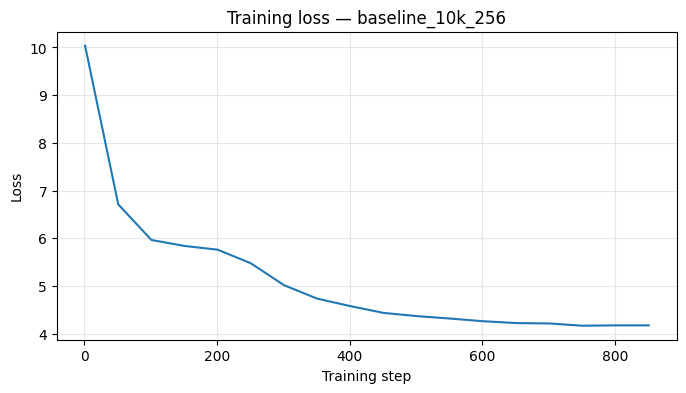

In [18]:
with open(experiment_dir / "metrics.json", "r") as f:
    metrics = json.load(f)

steps = np.arange(1, 50 * len(metrics["train_loss"]) + 1, 50)
losses = metrics["train_loss"]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses)

plt.title(f"Training loss — {EXPERIMENT}")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

In [23]:
for prompt in PROMPTS:
    print("=" * 80)
    print(f"PROMPT: {prompt}\n")

    text = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=100,
        temperature=0.8,
        seed=42
    )

    print(text)
    print()

PROMPT: Once upon a time a big bear

Once upon a time a big bear and friends. He was playing in a girl who loved to the ball. Inside that David was a rain and saw it.
One across a race,, it was very bit in the baby safe. They went to take a cage, "Yes, "
The voice were so happy to eat was a little boy replied about the nest.
One to get very feel special flying,”
When they played on, "It was too and said, "Sorry, "I want to

PROMPT: There was a little girl named Lily

There was a little girl named Lilymy. She stared for her momucky. One day, Lily felt excited to her momama one day, she liked to her mom across a books. She was special you a new mommy. Lily was very strange. Her room, she ran to her mommy, she could her mom said she took a bigap about her nest.
When she walked away together. His mommy didn't find her high on her great hair.
M said she told her looking to warm!" Everyone

PROMPT: One day Tom went into the forest

One day Tom went into the forest and friends. He was playing

# 25K stories

In [34]:
EXPERIMENT = "baseline_25k_256"
model, config, metrics = load_experiment(EXPERIMENT)

In [38]:
metrics_df = pd.DataFrame.from_dict(metrics)
metrics_df.head()

,epoch,step,loss,learning_rate
0,1,50,10.596505,0.000064
1,1,100,8.095605,0.000128
2,1,150,6.224899,0.000192
3,1,200,5.951338,0.000256
4,1,250,5.838405,0.000300


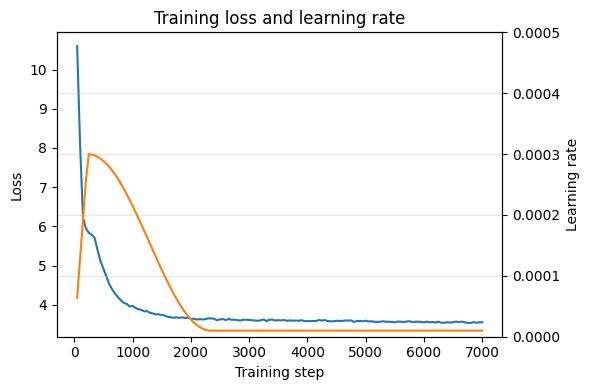

In [52]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Loss — left y-axis
ax1.plot(metrics_df["step"], metrics_df["loss"], label="Loss")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")

# Learning rate — right y-axis
ax2 = ax1.twinx()
ax2.plot(metrics_df["step"], metrics_df["learning_rate"], label="Learning rate", color="tab:orange")
ax2.set_ylabel("Learning rate")
ax2.set_ylim(0, 0.00050)

plt.title("Training loss and learning rate")
plt.grid(alpha=0.3)
fig.tight_layout()
plt.show()

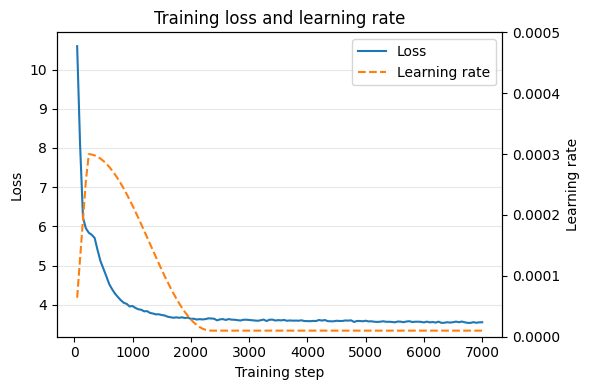

In [63]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Loss
loss_line, = ax1.plot(metrics_df["step"], metrics_df["loss"], label="Loss")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
plt.grid(axis="y", alpha=0.3)

# Learning rate
ax2 = ax1.twinx()
ax2.set_ylim(0, 0.00050)
lr_line, = ax2.plot(
    metrics_df["step"], metrics_df["learning_rate"],
    linestyle="--",
    label="Learning rate",
    color="tab:orange"
)
ax2.set_ylabel("Learning rate")

# Combined legend
ax1.legend(
    handles=[loss_line, lr_line],
    loc="upper right"
)

plt.title("Training loss and learning rate")
fig.tight_layout()
plt.show()

In [53]:
for prompt in PROMPTS:
    print("=" * 80)
    print(f"PROMPT: {prompt}\n")

    text = generate_text(
        model,
        tokenizer,
        prompt,
        max_new_tokens=100,
        temperature=0.8,
        seed=42
    )

    print(text)
    print()

PROMPT: Once upon a time a big bear

Once upon a time a big bear was friends. He was playing in a big tree with his backyard. The boat that was very curious. The little boy stping in the jungle.
One day, the sun decided to learn a big man. The bird started it was scared. He had so too. 
The cat was gentle. She grabbed him and he could see trying for a cat. It was flying in the boat. He was high on, he could not covered and too.

PROMPT: There was a little girl named Lily

There was a little girl named Lily. She was very very wrong. She wanted to take her mom and she clean her dad. Her mom said, "Mommy. Can I can't find it. Do you okay, she should make Lily.
She started it, she got an wish. Lily slipped on her toy and she was a little girl. She was very useful. She looked together. She met some things in the doll. The bowl and said, she was covered her toys.

PROMPT: One day Tom went into the forest

One day Tom went into the forest. It was very cute and wanted to do. One day, they saw 